In [88]:
import sys
sys.path.append("/Users/sujaladhikari/Sujal's Personal/Projects/FedIDS")

In [89]:
import os 
import shutil
import numpy as np 
import pandas as pd 
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
import torch 
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from Model.model import MLP
from torch.optim import Adam
import utils
from utils import JoinCustomDataset
from sklearn.metrics import classification_report
from federatedlearning import updatefrom_local, weight_averaging
from nids_training import evaluate_model
import matplotlib.pyplot as plt 

### Setting up the device

In [90]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device
RANDOMSEED = 42

### Creating the global model - using the same MLP used for the centralized model 

In [91]:
input_size = 78
hidden_layer = [256, 128,64,8]
num_classes = 2
global_model = MLP(input_size, hidden_layer,num_classes).to(device)
global_model
num_clients = 4

### Creating two folders that holds the training input data, and the other holds the result 

In [92]:
manual = ['One', 'Two', 'Three' , 'Four']
types = ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']
source_directory = '../silos_datasets/'
destination_directory  = './client_data/nids/' ## We are creating sub-directory in order to check on the future datasets.
os.makedirs(destination_directory , exist_ok=True)
for index,a in enumerate(manual):
    new_client_name = f'client_{index}'
    for type in types:
        old_file = f'silo{a}_{type}.csv'
        old_filepath = os.path.join(source_directory, old_file)
        
        new_file = f'{new_client_name}_{type}.csv'
        new_filepath = os.path.join(destination_directory , new_file)

        if os.path.exists(old_filepath):
            shutil.copy(old_filepath, new_filepath)

saving_directory = os.path.join('./output_nids/DNN_fedavg/nids') ## Creating the folder that stores the result of each client performance 
os.makedirs(saving_directory, exist_ok=True)

### Creating the Data Configuration and Training Configuration 


In [93]:
batch_size = 64 ## Initially we set up as same as the centralized model 
lr = 0.0001 ## different learning rate
num_rounds = 5 ## 5/.0001 => 50000 rounds 
num_local_epochs = 5
save_interval = 1

### We will be creating new dataset which contains all the testing data, that will keep on checking on how the global model is performing !?

### This will be the golden dataset that will contain 50% of the randomly sampled data from each of the testing data of the clients, and to make it more further we will be shuffling the data and will take the 100% of the whole shuffle data !

In [94]:
## Creating an ultimate gloden dataset 
golden_data = []
path = './client_data/nids/'
for i in range(num_clients):
    filepath = os.path.join(path, f'client_{i}_X_test.csv')
    testfilepath = os.path.join(path, f'client_{i}_y_test.csv')
    if os.path.exists(filepath) and os.path.exists(testfilepath):
        x_test_data = pd.read_csv(filepath)
        test_data = pd.read_csv(testfilepath)
        combined_data = pd.concat([x_test_data,test_data], axis = 1)
        golden_data.append(combined_data)


global_dataset = pd.concat(golden_data, ignore_index=True)
## Randomly shuffling the dataset 
global_dataset = global_dataset.sample(frac = 1, random_state = RANDOMSEED).reset_index(drop = True)
global_dataset.head(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label_Binary
0,5002,43,1,1,2,6,2,2,2.000000,0.000000,...,24,0.00000,0.00000,0,0,0.0,0.00000,0,0,1
1,443,60414768,14,16,718,4337,367,0,51.285714,110.881384,...,32,40929.66667,39340.51837,121233,24725,10000000.0,11414.67646,10000000,9994667,0
2,53,255,2,2,60,344,30,30,30.000000,0.000000,...,32,0.00000,0.00000,0,0,0.0,0.00000,0,0,0
3,545,42,1,1,2,6,2,2,2.000000,0.000000,...,24,0.00000,0.00000,0,0,0.0,0.00000,0,0,1
4,80,113616,3,0,0,0,0,0,0.000000,0.000000,...,32,0.00000,0.00000,0,0,0.0,0.00000,0,0,0


In [95]:
X = global_dataset.drop(columns = ['Label_Binary']).values
y = global_dataset['Label_Binary'].values

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype = torch.long)


global_tuple = (X_tensor,y_tensor)

### Two Global Metrics for the global model 

In [96]:
performance_dict, performance_log = dict(), dict()
metric_keys = ['g_train_loss', 'g_test_loss']
performance_dict, performance_log = utils.performance_analyzer(metric_keys)

In [97]:
labmda = 0.01

### Loading all the client data before training them to the global model 


In [98]:
client_loaders = [] ## It has four dataloaders for each client 
for index in range(num_clients):
    features_path = f'client_{index}_X_train.csv'
    labels_path = f'client_{index}_y_train.csv'
    features_directory = os.path.join(destination_directory, features_path )
    labels_directory = os.path.join(destination_directory, labels_path) 
    dataset = utils.JoinCustomDataset(features_directory, labels_directory)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size = batch_size, shuffle = True) ## The batch size is 64
    client_loaders.append(dataloader)


### Creating a test loader for each client to check the test loss 

In [99]:
validation_loaders = []
for index in range(num_clients):
    features_path = f'client_{index}_X_val.csv'
    labels_path = f'client_{index}_y_val.csv'
    features_directory = os.path.join(destination_directory, features_path )
    labels_directory = os.path.join(destination_directory, labels_path)
    print(features_directory,labels_directory)
    dataset = utils.JoinCustomDataset(features_directory, labels_directory)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size = batch_size, shuffle = True)
    validation_loaders.append(dataloader)

./client_data/nids/client_0_X_val.csv ./client_data/nids/client_0_y_val.csv
./client_data/nids/client_1_X_val.csv ./client_data/nids/client_1_y_val.csv
./client_data/nids/client_2_X_val.csv ./client_data/nids/client_2_y_val.csv
./client_data/nids/client_3_X_val.csv ./client_data/nids/client_3_y_val.csv


### Automatically resuming from the checkpoint 


In [100]:
# Checking if there is already anything going on 
log_path = os.path.join(saving_directory, 'performanance_log.pickle')
if os.path.isfile(log_path):
    performance_log = utils.loading_pickle(log_path)
starting_round = len(performance_log[metric_keys[0]]) ## Check the list of the stored values (g_train), if the value is greaeter thean 0 then the model is already started and doing its job, and if the model crashes then it can continue from where it left!
if starting_round > 0:
    global_model.load_state_dict(torch.load(os.path.join(saving_directory, 'g_r_{}.pth').format(starting_round))) ## The global model takes the weight from where it left 

In [101]:
global_weights = global_model.state_dict() ## This gives the initial weights of the given model
loss_function = nn.CrossEntropyLoss()
optimization_args = {'lr':lr}

### Starting of the model 

### We wll be looping the model from start round to number of rounds
### Here the starting round is initially zero as nothing is loaded in the given model 

for round_number in range(starting_round, num_rounds): ## Initially 0 -> 5
    print('Round Number:', round_number) 
    global_model.train()
    client_updates = dict() ## We will be storing the updates given by clients in a dictionary 
    for client_number in range(num_clients): ## Looping through each client
        print('Client:', client_number) ## Printing out the client number 
        client_loader = client_loaders[client_number] ## Loading the each client data 
        validation_loader = validation_loaders[client_number] ## Loading each validation data 
        client_update = updatefrom_local(global_model,client_loader, validation_loader, num_local_epochs, optimization_args) 
        client_updates.setdefault('local_weights', list()).append(client_update['local_weights'])
        client_updates.setdefault('num_samples', list()).append(client_update['num_samples'])

        ## Performance log update 
        performance_log.setdefault('c_{}_train_loss'.format(client_number), list()).append(client_update['train_loss'])
        ## Train loss of each client using the global model on training data 
        performance_log.setdefault('c_{}_test_loss'.format(client_number), list()).append(client_update['test_loss'])

    
    global_weights = weight_averaging(client_updates['local_weights'], client_updates['num_samples'], device)
    global_model.load_state_dict(global_weights) ## Updating the weights to the global model 

    ## Evaluating the global model on local dataset in each round 
    for client_index in range(num_clients):
        g_train_loss = evaluate_model(global_model, client_loaders[client_index], loss_function, tqdm_desc = 'g_train_loss')
        performance_dict['g_train_loss'].update_state(g_train_loss)
        g_test_loss = evaluate_model(global_model, validation_loaders[client_index], loss_function, tqdm_desc='Validation Loss' )
        performance_dict['g_test_loss'].update_state(g_test_loss)
    
    performance_log['g_train_loss'].append(performance_dict['g_train_loss'].result())
    performance_log['g_test_loss'].append(performance_dict['g_test_loss'].result())
    performance_dict['g_train_loss'].reset_state()
    performance_dict['g_test_loss'].reset_state()

    for metric in metric_keys:
        print(f"{metric}: {performance_log[metric][-1]}")

    ## Saving the global model 

    if (round_number + 1)  % save_interval == 0: 
        torch.save(global_model.state_dict(), os.path.join(saving_directory, 'g_r_{}.pth'.format(round_number+1))) ## Saving the global model's weights in the given directory with the name g_r_1..n.pth
        utils.savein_pickle(log_path,performance_log)  ## Storing the overall value in the pickle form to access it later 
    

### The global weight is updated in each round where the weight of each client for each layer is stored in the client updates which is then sent to weight_averaging which averages the weight based on the samples size


Round Number: 0
Client: 0


Local Testing Loss: 100%|██████████| 1180/1180 [00:01<00:00, 951.23it/s]


Client: 1


Local Testing Loss: 100%|██████████| 1354/1354 [00:02<00:00, 622.97it/s]


Client: 2


...

Client: 2


Local Testing Loss: 100%|██████████| 65/65 [00:00<00:00, 905.77it/s]


Client: 3


Validation Loss: 100%|██████████| 11/11 [00:00<00:00, 796.64it/s]

g_train_loss: 38.10113525390625
g_test_loss: 38.56129455566406


### Making a dataframe that stores all the test loss and train loss of each client and global model in each round



In [102]:
import pickle
with open('./output_nids/DNN_fedavg/nids/performanance_log.pickle', 'rb') as f:
    losses = pickle.load(f)

data = pd.DataFrame(losses)
data.index.name = 'Round'
data = data.reset_index()
data.head(5)

,Round,g_train_loss,g_test_loss,c_0_train_loss,c_0_test_loss,c_1_train_loss,c_1_test_loss,c_2_train_loss,c_2_test_loss,c_3_train_loss,c_3_test_loss
0,0,18.198006,18.437315,0.216693,0.208513,0.172331,0.210232,5.512517,4.137488,16.548563,697.883362
1,1,9.607764,9.787641,0.162932,0.140247,0.123480,0.189777,0.145542,0.194416,0.156331,0.130972
2,2,19.737749,20.014711,0.084115,0.076865,0.069126,0.086754,0.111957,0.115702,0.090897,0.088086
3,3,18.735779,19.009085,0.054830,0.060142,0.072912,0.143827,0.110066,0.097560,0.092088,0.092323
4,4,38.101135,38.561295,0.061335,0.062333,0.054262,0.060026,0.065643,0.055738,0.067883,0.088974


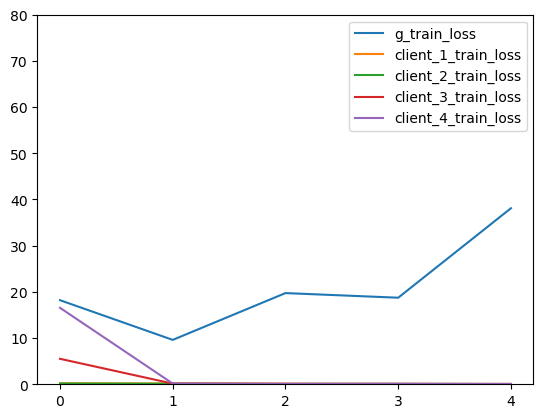

In [103]:
plt.plot(data['g_train_loss'], label = 'g_train_loss')
plt.plot(data['c_0_train_loss'], label = 'client_1_train_loss')
plt.plot(data['c_1_train_loss'], label = 'client_2_train_loss')
plt.plot(data['c_2_train_loss'], label = 'client_3_train_loss')
plt.plot(data['c_3_train_loss'], label = 'client_4_train_loss')
plt.xticks(np.arange(0,5,1))
plt.ylim(0,80)
plt.legend()
plt.show()

In [ ]:
plt.plot(data['g_test_loss'], label = 'g_test_loss')
plt.plot(data['c_0_test_loss'], label = 'client_0_test_loss')
plt.plot(data['c_1_test_loss'], label = 'client_1_test_loss')
plt.plot(data['c_2_test_loss'], label = 'client_2_test_loss')
plt.plot(data['c_3_test_loss'], label = 'client_3_test_loss')
plt.xticks(np.arange(0,5,1))
plt.ylim(0,80)
plt.legend()
plt.show()

In [105]:
print(global_model)
print(global_model.state_dict())

MLP(
  (fc_layers): ModuleList(
    (0): Linear(in_features=78, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.001)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.001)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): LeakyReLU(negative_slope=0.001)
    (6): Linear(in_features=64, out_features=8, bias=True)
    (7): LeakyReLU(negative_slope=0.001)
    (8): Linear(in_features=8, out_features=2, bias=True)
  )
)
OrderedDict([('fc_layers.0.weight', tensor([[ 0.1045,  0.0654, -0.2413,  ...,  0.0659, -0.0876, -0.1093],
        [ 0.6831, -0.0702, -0.1574,  ..., -0.0051,  0.0025, -0.0922],
        [ 0.0362,  0.0091, -0.3133,  ..., -0.0287, -0.0505, -0.1295],
        ...,
        [ 0.6465,  0.0479, -0.3858,  ..., -0.1640, -0.1337, -0.0533],
        [-0.7466, -0.0330,  0.5865,  ..., -0.0343,  0.0179, -0.0255],
        [-0.8412,  0.0675, -0.5275,  ...,  0.0230,  0.0500, -0.0861]],
       device='mps:0')), ('

---
### Evaluating the global model on combined test data vs individual datas

In [ ]:
criterion = nn.CrossEntropyLoss()
def post_trained_global_model(model, test_loader, criterion, device):
    model.eval()
    train_loss = 0.0
    test_loss = 0.0
    total = []
    predicted = []